This notebook calculates replicate correlation for each strain.

In [664]:
import pandas as pd

In [665]:
import os

strain = "NBC_01790"
outdir = "/Users/annasve/Desktop/article_data/output/replicate_correlation/NBC_01790/"

os.makedirs(outdir, exist_ok=True)

In [666]:
file_path = '/Users/annasve/Desktop/article_data/expression_module/NBC_01790/NBC_01790_genes_with_refined_bgc_borders.xlsx'
df = pd.read_excel(file_path)

In [667]:
df.head()

,Geneid,1790-DNPM-1,1790-DNPM-2,1790-ISP2-1,1790-ISP2-2,1790-MA-1,1790-MA-2,1790-SoyM-1,1790-SoyM-2,1790-TSB-1,...,start,site_sequence,E_value,significant_site,BGC_region,BGC_block,__gorder__,low_expression_rule,Region_Nr_original,BGC_ID
0,OHB02_00005,4.027595,4.042705,4.737169,5.161814,5.130554,5.213614,5.528094,4.730613,4.685823,...,NaN,NaN,NaN,NaN,NaN,NaN,0,False,NaN,NaN
1,OHB02_00010,2.396200,2.626893,3.535002,3.638910,3.255820,3.924879,3.804074,2.852261,2.973082,...,NaN,NaN,NaN,NaN,NaN,NaN,1,False,NaN,NaN
2,OHB02_00015,1.213560,0.787925,2.207137,2.116947,1.845763,2.299063,2.677833,1.655046,1.547648,...,NaN,NaN,NaN,NaN,NaN,NaN,2,False,NaN,NaN
3,OHB02_00020,1.430769,1.603186,2.341354,1.625107,1.785245,1.487820,1.349854,1.705266,0.590538,...,NaN,NaN,NaN,NaN,NaN,NaN,3,False,NaN,NaN
4,OHB02_00025,3.003007,2.883073,3.081511,1.998589,2.892282,3.797697,3.205395,3.226570,1.723351,...,NaN,NaN,NaN,NaN,NaN,NaN,4,False,NaN,NaN


In [668]:
media = ["DNPM", "ISP2", "MA", "SoyM", "TSB", "gluc", "gly", "malt"]

# keep only columns containing one of the media names
sample_cols = [c for c in df.columns if any(m in c for m in media)]

expr = df[sample_cols].copy()

print(expr.shape)
print(expr.columns)

(5945, 16)
Index(['1790-DNPM-1', '1790-DNPM-2', '1790-ISP2-1', '1790-ISP2-2', '1790-MA-1',
       '1790-MA-2', '1790-SoyM-1', '1790-SoyM-2', '1790-TSB-1', '1790-TSB-2',
       '1790-gluc-3', '1790-gluc-4', '1790-gly-3', '1790-gly-4', '1790-malt-1',
       '1790-malt-2'],
      dtype='object')


In [669]:
sample_info = pd.DataFrame({
    "sample": expr.columns
})

sample_info["media"] = sample_info["sample"].str.extract(
    r'(DNPM|ISP2|MA|SoyM|TSB|gluc|gly|malt)'
)

print(sample_info)

         sample media
0   1790-DNPM-1  DNPM
1   1790-DNPM-2  DNPM
2   1790-ISP2-1  ISP2
3   1790-ISP2-2  ISP2
4     1790-MA-1    MA
5     1790-MA-2    MA
6   1790-SoyM-1  SoyM
7   1790-SoyM-2  SoyM
8    1790-TSB-1   TSB
9    1790-TSB-2   TSB
10  1790-gluc-3  gluc
11  1790-gluc-4  gluc
12   1790-gly-3   gly
13   1790-gly-4   gly
14  1790-malt-1  malt
15  1790-malt-2  malt


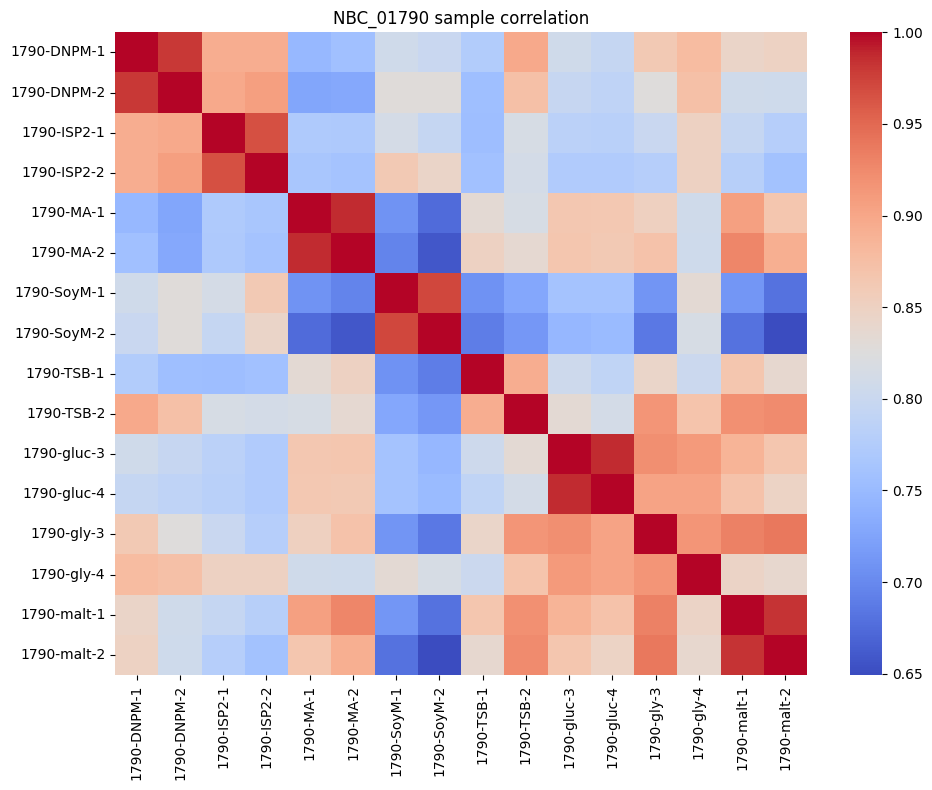

In [670]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(expr.corr(), cmap="coolwarm")

plt.title(f"{strain} sample correlation")

plt.tight_layout()

plt.savefig(
    os.path.join(outdir, f"{strain}_sample_correlation_heatmap.png"),
    dpi=300
)



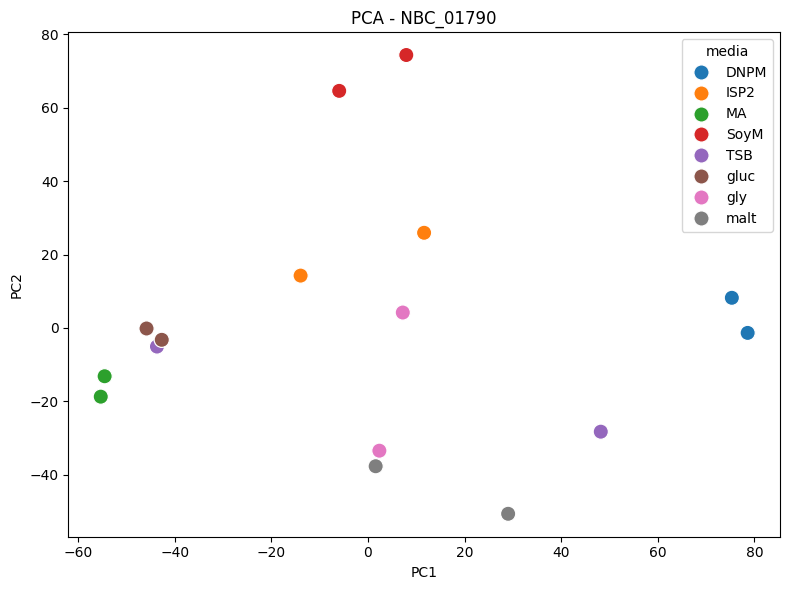

In [671]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = expr.T
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(pcs, columns=["PC1","PC2"])
pca_df["media"] = sample_info["media"]
pca_df["sample"] = sample_info["sample"]

plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="media", s=120)

plt.title(f"PCA - {strain}")

plt.tight_layout()

plt.savefig(
    os.path.join(outdir, f"{strain}_PCA_media.png"),
    dpi=300
)



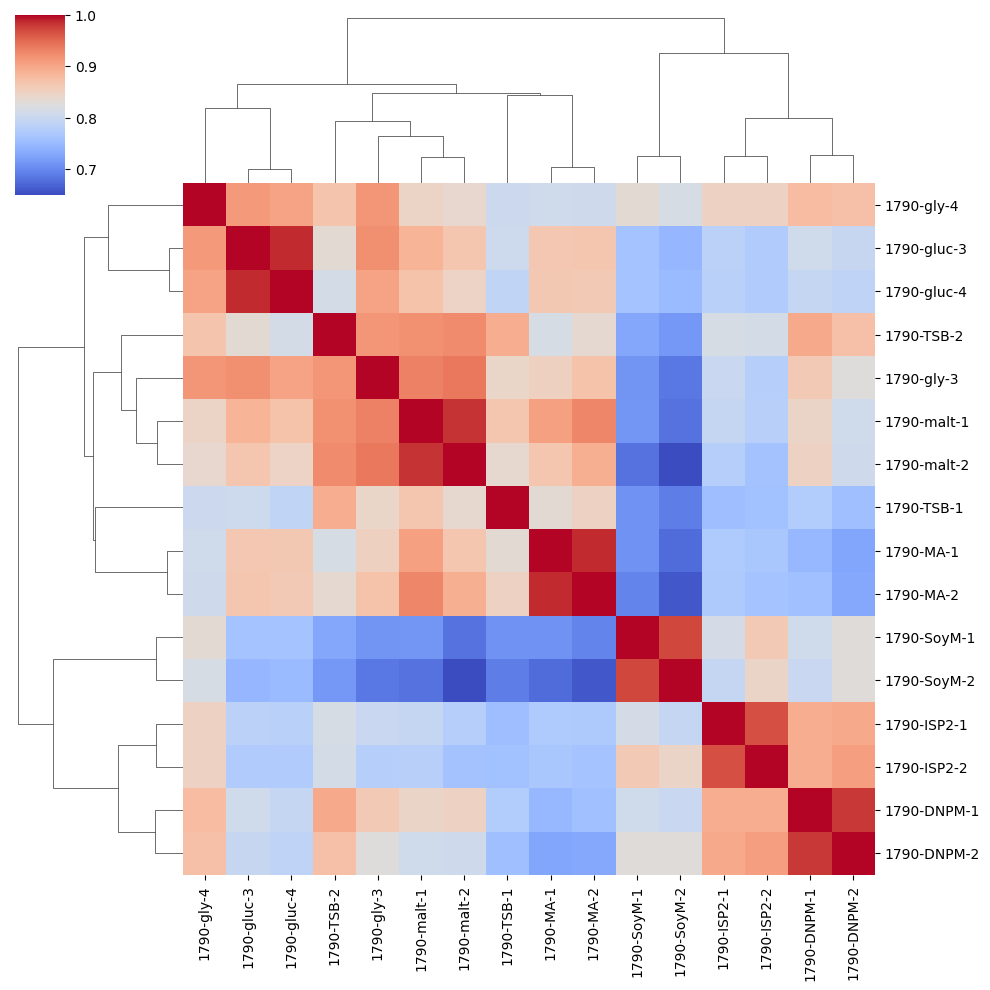

In [672]:
sns.clustermap(expr.corr(), cmap="coolwarm", figsize=(10,10))

plt.savefig(
    os.path.join(outdir, f"{strain}_sample_clustering.png"),
    dpi=300
)



In [673]:

results = []

for m in media:
    samples = sample_info.loc[sample_info["media"] == m, "sample"].tolist()

    if len(samples) < 2:
        results.append({
            "Strain": strain,
            "media": m,
            "replicates": len(samples),
            "mean_corr": np.nan,
            "min_corr": np.nan
        })
        print(f"Skipping {m}: only {len(samples)} sample(s)")
        continue

    corr = expr[samples].corr()
    vals = corr.values[np.triu_indices_from(corr, k=1)]

    results.append({
        "Strain": strain,
        "media": m,
        "replicates": len(samples),
        "mean_corr": np.mean(vals),
        "min_corr": np.min(vals)
    })

replicate_quality = pd.DataFrame(results)

print(replicate_quality)

replicate_quality.to_csv(
    os.path.join(outdir, f"{strain}_replicate_quality.csv"),
    index=False
)

      Strain media  replicates  mean_corr  min_corr
0  NBC_01790  DNPM           2   0.979642  0.979642
1  NBC_01790  ISP2           2   0.966334  0.966334
2  NBC_01790    MA           2   0.987426  0.987426
3  NBC_01790  SoyM           2   0.972276  0.972276
4  NBC_01790   TSB           2   0.894270  0.894270
5  NBC_01790  gluc           2   0.987276  0.987276
6  NBC_01790   gly           2   0.916111  0.916111
7  NBC_01790  malt           2   0.982758  0.982758


In [674]:
replicate_quality.to_excel(os.path.join(outdir, 'NBC_01790_replicate_quality.xlsx'), index=False)